# A comparison of holography X-ray phase contrast imaging:

# mean intensity vs intensity correlations

X-ray holography with intensity correlations is given by the following forward problem:
$$F(f)=c_{f} ~~\text{with}~~ c_{f}(x,y):=\operatorname{Cov}(I(x),I(y)),~~\text{and}~~I:=|\mathcal{D}e^{f}u|^2 $$
The forward operator is given by:
$$
F(f):=|\mathcal{D}M_{\exp(f)}\operatorname{Cov}[u]M_{\exp(f)}^*\mathcal{D}^*|^2.
$$
In contrast to the imaging from intensity correlations, the X-ray holography with mean intensity is given by the following forward problem:
$$G(f)=d_{f} ~~\text{with}~~d_{f}(x):=c_{f}(x,x)=\mathbb{E}[I(x)]^2$$
The forward operator is given by:
$$
G(f):=\operatorname{Diag}(\mathcal{D}M_{\exp(f)}\operatorname{Cov}[u]M_{\exp(f)}^*\mathcal{D}^*).
$$

In [1]:
import os
import sys

#sys.path.append(os.path.join(os.path.dirname(__file__), '../../'))

from regpy.hilbert import L2
from regpy.vecsps import UniformGridFcts
from regpy.vecsps import NumPyVectorSpace
from regpy.solvers import TikhonovRegularizationSetting
from regpy.solvers.nonlinear.fista import FISTA
import regpy.stoprules as rules
from regpy.operators import SquaredModulus, VectorOfOperators, Identity, RealPart, ImaginaryPart
from regpy.functionals import QuadraticNonneg, QuadraticBilateralConstraints
import matplotlib.pyplot as plt
#from regpy.operators.fresnel import fresnel_propagator

from auxiliary_ops import ReIm, summation, fresnel_prop,  Proj, Reshape
from phaseless_passive_ip_ops import Contrast2FactorPhasedCovOp,  Tau, MatrixAutoProductOp, DiagMatrixAutoProductOp 
from low_rank_op_misfit_fct import HilbertSchmidtLowRank
from create_Vcov import _create_Vcov
from graphic_utils import test_image_cells, test_image_circle_cross, show_measurements, show_results, show_comparison_results

import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)-20s :: %(message)s'
)


# Create forward operators and synthetic data

Setting up parameters 

In [2]:
N=128                             # Pixel number in each spatial direction
contrast = test_image_circle_cross(N,N)
#contrast = test_image_cells()
N_frame=3000                      # Number of frames ( or realizations)
T=1e9                             # the observation time or the number of photon counts
fresnel_number=10                 # not properly scaled
N_b=4                             # denotes the rank of the matrix V

Create a uniform grid

In [ ]:
xsample=np.arange(-1,1-1/N,2/N)
ysample=xsample
grid=UniformGridFcts((-1, 1, N), (-1, 1, N), dtype=complex)
grid_domain=UniformGridFcts((-1, 1, 2), (-1, 1, N), (-1, 1, N))
grid_codomain_6=NumPyVectorSpace((N, N))


construct decomposition $\operatorname{Cov}[u]=VV^*$ of the source covariance operator 

In [4]:
create_types=['spatial', 'Fresnelprop', 'fourier_random']
create_type='fourier_random'
sigma=0.5                         # parameter used in the rapid deacaying function

Vcov, S=_create_Vcov(N, N_b, create_type=create_type, grid=grid, sigma=sigma, xsample=xsample, ysample=ysample)
# here S is the singular values of the matrix V
Vcov = Vcov * (1./S)[(None,None,...)]

compute forward operators 

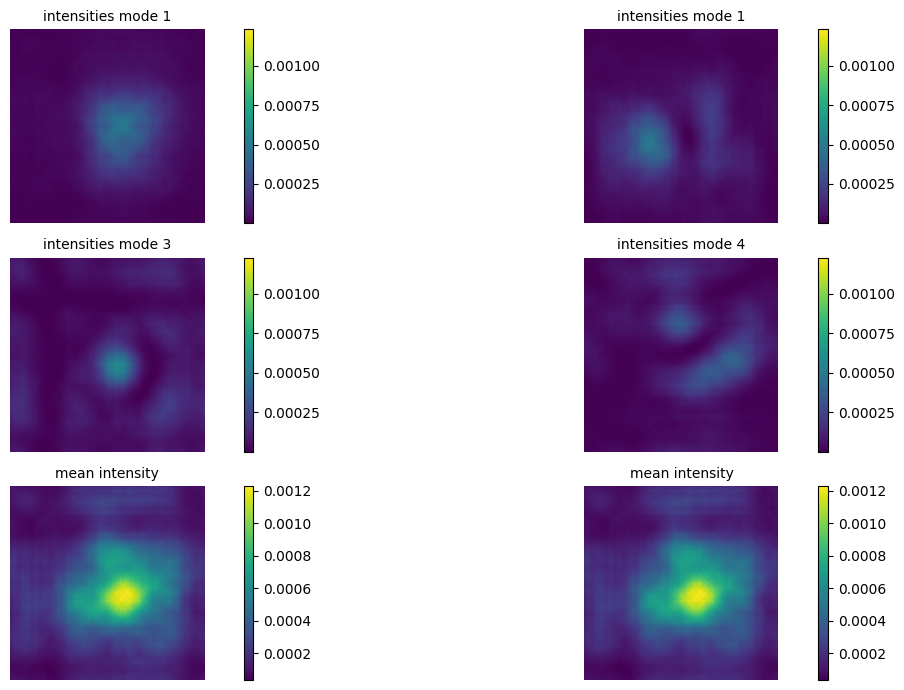

In [5]:
fp=fresnel_prop(grid, number=complex(0, 1)/(2*fresnel_number))   # Fresenel propagation operator

Mat_op=Contrast2FactorPhasedCovOp(Vcov,fp)
Tau_op=Tau(NumPyVectorSpace(shape=(N_b,),dtype=complex), NumPyVectorSpace(shape=(N,N),dtype=complex))
MatMul = MatrixAutoProductOp(Tau_op.codomain,ndim_col=2)
ReIm_op=ReIm(grid, grid_domain)

# forward operator associated with the intensity correlations
op_intcorr = MatMul*Tau_op*Mat_op * ReIm_op.adjoint

# forward operator associated with the mean intensity
power=SquaredModulus(grid_codomain)
trace=summation(power.codomain, grid_codomain_6)
op_meanint=trace*power*Mat_op*ReIm_op.adjoint

fig=show_measurements(Mat_op(contrast))

Create synthetic intensity data 

In [6]:
ptw_detection= SquaredModulus(grid)
taumat_0=Mat_op(contrast) 
data_meanint=np.zeros((N, N))   # mean intensity 
intensities=np.zeros((N_frame, N, N))

for i in range(0, N_frame):
    random=1/np.sqrt(2)*(np.random.randn(N_b)+complex(0,1)*np.random.randn(N_b))
    uinc=np.tensordot(taumat_0, random, axes=([-1], [0]))
    signal=ptw_detection(uinc)
    
    #Cox-process
    signal=(1/T)*np.random.poisson(lam=T*signal.flatten(), size=(N**2)).reshape(N, N)
    data_meanint += signal
    intensities[i, :, :]=signal
    
data_meanint /= N_frame

# centering of  intensities
intensities -= data_meanint


# Inversions
Both for mean intensity data and for intensity correlations we use Tikhonov regularization with L^2 data fidelity term and an L^2 penalty term 
incorporating a non-negativity constraint. The regularization parameter is decreased gradually, using the minimizer of the previous Tikhonov functional as initial guess for the next one. Minimizers of the Tikhonov functional are computed by the FISTA algorithm.

## Inversion for mean intensity

initialize inversions

In [7]:
regpar_meanint = 3e-4    # initial regularization parameter
Nfista_meanint = 10      # number of FISTA steps for each value of the regularization parameter

penalty=QuadraticNonneg(ReIm_op.codomain)

setting_mean_inten = TikhonovRegularizationSetting(op=op_meanint, penalty=penalty, data_fid = L2, 
                                        data_fid_shift=data_meanint,regpar=regpar_meanint)

reco_meanint = np.zeros_like(contrast)   # initial guess is zero
mean_int_stats = []                      # reconstructions and errors for each regularization parameter will stored   

iteratively decrease the regularization parameter

2025-09-19 00:14:12,107 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.000e-04, mu_S=0.000e+00 and step length tau=4.523e+02.
 Expected linear convergence rate: 7.920e-01
2025-09-19 00:14:12,219 INFO FISTA                :: Solver converged after 10 iteration.


error_meanint = 0.5070618053518575, alpha= 9.999999999999999e-05


2025-09-19 00:14:13,135 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=3.333e-05, mu_S=0.000e+00 and step length tau=4.527e+02.
 Expected linear convergence rate: 8.781e-01
2025-09-19 00:14:13,256 INFO FISTA                :: Solver converged after 10 iteration.


error_meanint = 0.4846390207996983, alpha= 3.333333333333333e-05


2025-09-19 00:14:14,358 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.111e-05, mu_S=0.000e+00 and step length tau=4.524e+02.
 Expected linear convergence rate: 9.293e-01
2025-09-19 00:14:14,466 INFO FISTA                :: Solver converged after 10 iteration.


...

error_meanint = 0.47565973609495615, alpha= 4.572473708276176e-08


2025-09-19 00:14:20,415 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.524e-08, mu_S=0.000e+00 and step length tau=4.525e+02.
 Expected linear convergence rate: 9.974e-01
2025-09-19 00:14:20,519 INFO FISTA                :: Solver converged after 10 iteration.


error_meanint = 0.4756485573155897, alpha= 1.5241579027587254e-08


2025-09-19 00:14:21,252 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=5.081e-09, mu_S=0.000e+00 and step length tau=4.525e+02.
 Expected linear convergence rate: 9.985e-01
2025-09-19 00:14:21,357 INFO FISTA                :: Solver converged after 10 iteration.


error_meanint = 0.475646133140331, alpha= 5.080526342529085e-09


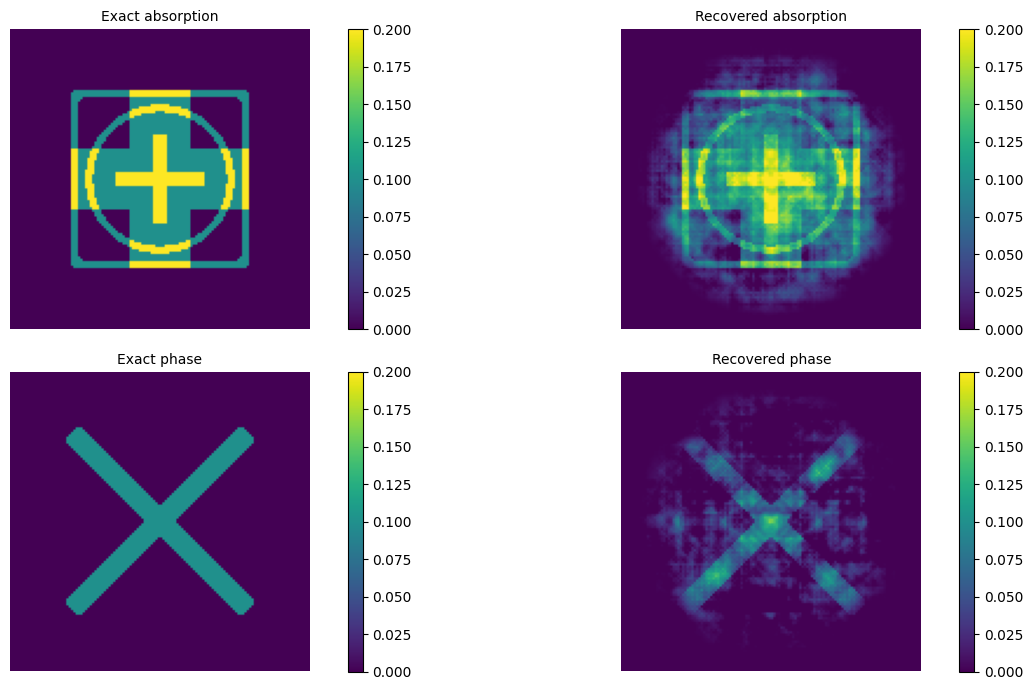

In [8]:
for _ in range(10):
    setting_mean_inten.regpar = setting_mean_inten.regpar/3.
    setting_mean_inten.init = reco_meanint
    FISTA_solver = FISTA(setting_mean_inten,without_codomain_vectors=False,logging_level="INFO")
    stoprule = rules.CountIterations(Nfista_meanint,logging_level="WARN")
    reco_meanint, reco_data_meanint=FISTA_solver.run(stoprule)
    reco_meanint=ReIm_op.adjoint(reco_meanint)

    error_meanint=np.linalg.norm(reco_meanint-contrast)/np.linalg.norm(contrast)
    print(f"error_meanint = {error_meanint}, alpha= {setting_mean_inten.regpar}")
    mean_int_stats.append([reco_meanint,error_meanint,setting_mean_inten.regpar])
show_results(contrast,reco_meanint)

## Inversion for intensity correlations

initialize inversions

In [9]:
regpar_intcorr = 1e-7     # initial regularization parameter
Nfista_intcorr = 10       # number of FISTA steps for each value of the regularization parameter

penalty=QuadraticNonneg(ReIm_op.codomain)

#reco_intcorr = None # use this for ab initio reconstruction based on intensity correlations
reco_intcorr = reco_meanint # use this for a warm start from mean intensity reconstruction

setting_intcorr = TikhonovRegularizationSetting(op=op_intcorr, penalty=penalty, data_fid = L2,
                                            regpar=regpar_intcorr)

intcorr_stats = []

iteratively decrease the regularization parameter

2025-09-19 00:14:22,961 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=3.333e-08, mu_S=0.000e+00 and step length tau=1.944e+05.
 Expected linear convergence rate: 9.198e-01
2025-09-19 00:14:22,961 INFO CountIterations      :: iteration = 1 / 10
2025-09-19 00:14:25,339 INFO CountIterations      :: iteration = 2 / 10
2025-09-19 00:14:27,902 INFO CountIterations      :: iteration = 3 / 10
2025-09-19 00:14:30,176 INFO CountIterations      :: iteration = 4 / 10
2025-09-19 00:14:32,679 INFO CountIterations      :: iteration = 5 / 10
2025-09-19 00:14:35,141 INFO CountIterations      :: iteration = 6 / 10
2025-09-19 00:14:37,651 INFO CountIterations      :: iteration = 7 / 10
2025-09-19 00:14:40,229 INFO CountIterations      :: iteration = 8 / 10
2025-09-19 00:14:42,582 INFO CountIterations      :: iteration = 9 / 10
2025-09-19 00:14:44,979 INFO CountIterations      :: iteration = 10 / 10
2025-09-19 00:14:47,330 INFO FISTA                :: Solver converged after 

error_intcorr = 0.41533566281097023, alpha= 3.3333333333333334e-08


2025-09-19 00:14:48,539 INFO FISTA                :: Setting up FISTA with convexity parameters mu_R=1.111e-08, mu_S=0.000e+00 and step length tau=1.854e+05.
 Expected linear convergence rate: 9.547e-01
2025-09-19 00:14:48,539 INFO CountIterations      :: iteration = 1 / 10
2025-09-19 00:14:51,045 INFO CountIterations      :: iteration = 2 / 10
2025-09-19 00:14:53,430 INFO CountIterations      :: iteration = 3 / 10
2025-09-19 00:14:55,850 INFO CountIterations      :: iteration = 4 / 10
2025-09-19 00:14:58,434 INFO CountIterations      :: iteration = 5 / 10
2025-09-19 00:15:01,079 INFO CountIterations      :: iteration = 6 / 10
2025-09-19 00:15:03,580 INFO CountIterations      :: iteration = 7 / 10
2025-09-19 00:15:05,913 INFO CountIterations      :: iteration = 8 / 10
2025-09-19 00:15:08,341 INFO CountIterations      :: iteration = 9 / 10
2025-09-19 00:15:10,737 INFO CountIterations      :: iteration = 10 / 10
2025-09-19 00:15:13,142 INFO FISTA                :: Solver converged after 

error_intcorr = 0.39557540366935146, alpha= 1.1111111111111112e-08


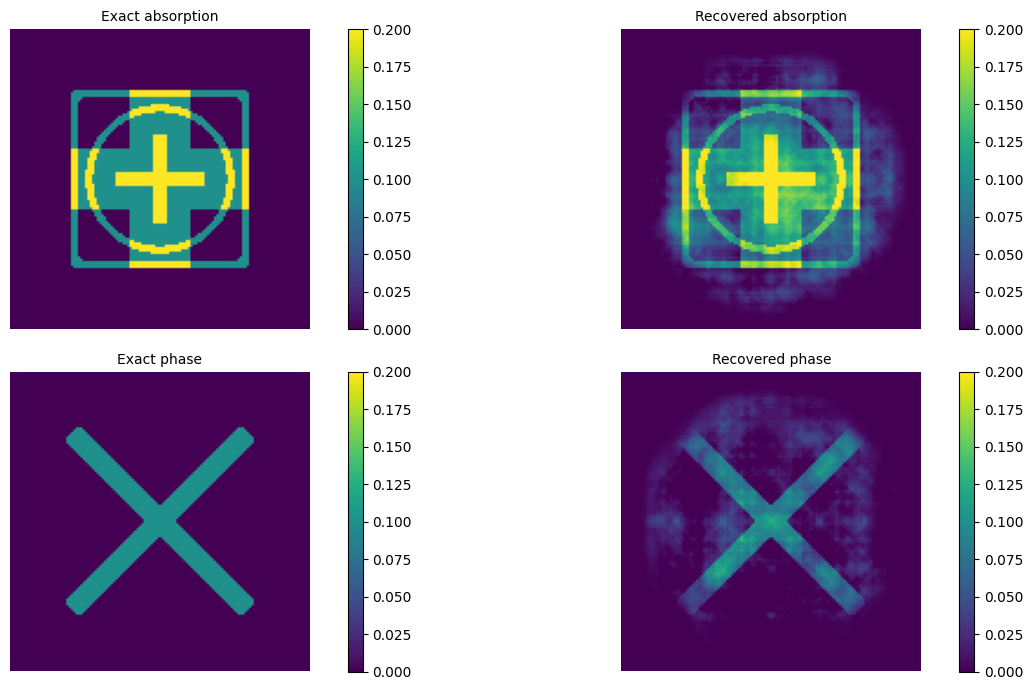

In [10]:
for _ in range(2):
    setting_intcorr.regpar = setting_intcorr.regpar/3.
    setting_intcorr.init = reco_intcorr
    FISTA_solver = FISTA(setting_intcorr,data=intensities,without_codomain_vectors=True,
                        init=ReIm_op(reco_intcorr))
    stoprule = (rules.CountIterations(Nfista_intcorr))
    reco_intcorr, reco_data_intcorr=FISTA_solver.run(stoprule)
    reco_intcorr=ReIm_op.adjoint(reco_intcorr)

    error_intcorr=np.linalg.norm(reco_intcorr-contrast)/np.linalg.norm(contrast)
    print(f"error_intcorr = {error_intcorr}, alpha= {setting_intcorr.regpar}",)
    intcorr_stats.append([reco_intcorr,error_intcorr,setting_intcorr.regpar])
show_results(contrast,reco_intcorr)


## Comparative plots

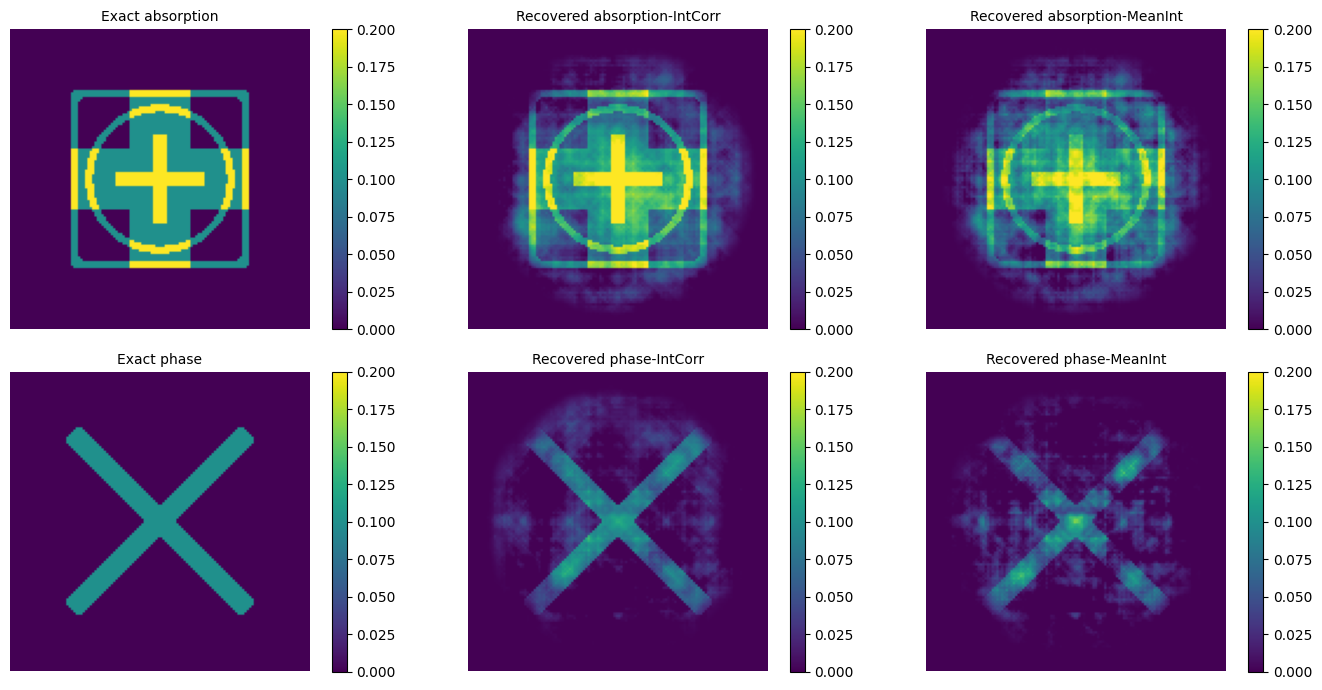

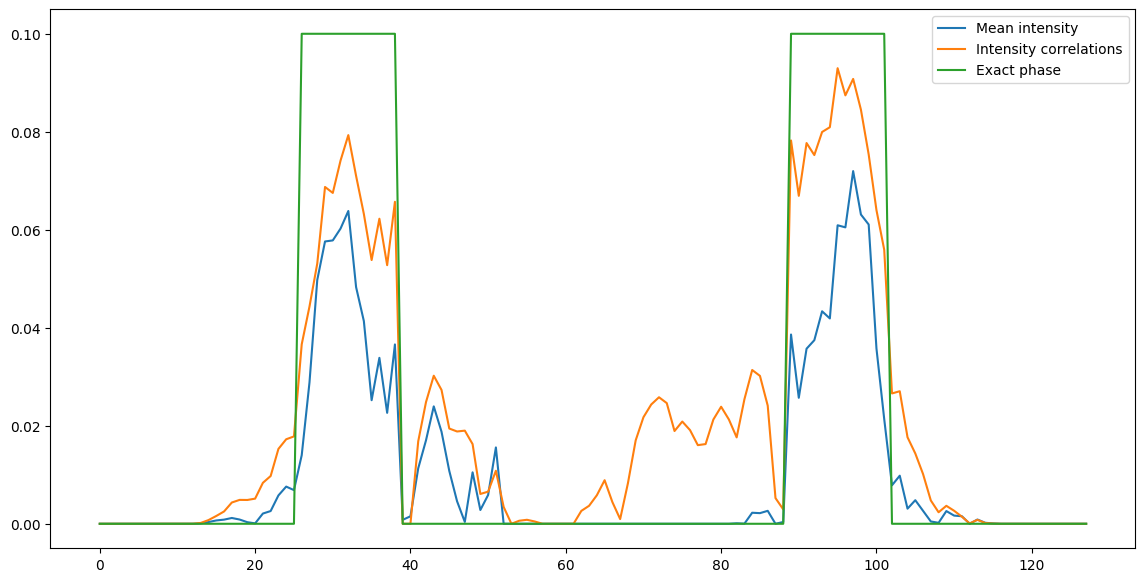

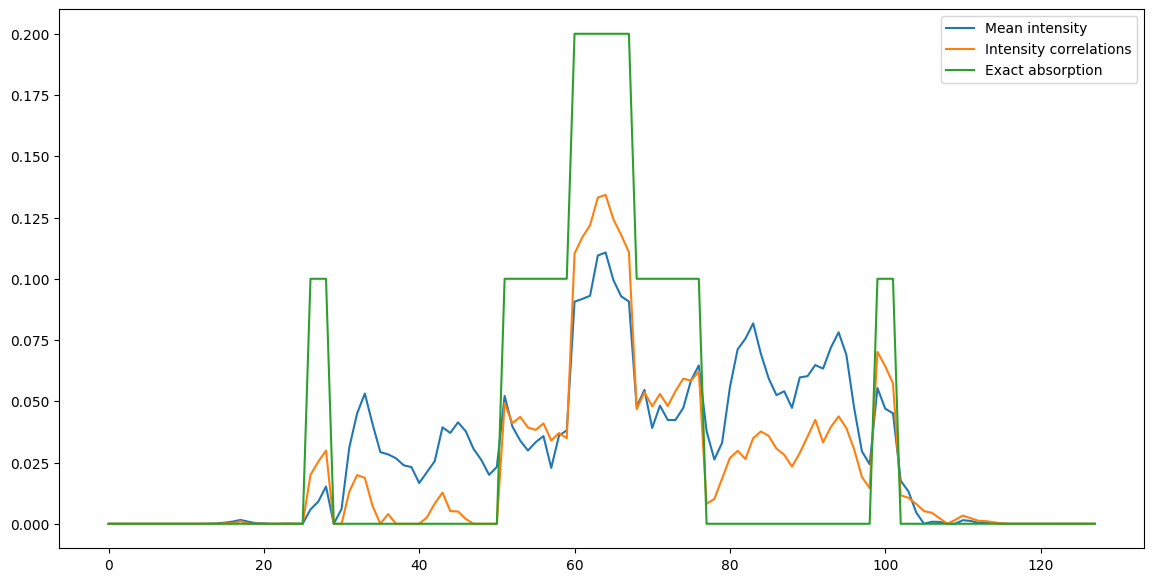

In [11]:
show_comparison_results(contrast,reco_intcorr,reco_meanint)

